In [3]:
# Optional: silence sklearn FutureWarnings in logs
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

# Ensure we can import ../src from notebooks/
import sys, os
from pathlib import Path
here = Path.cwd()
for p in [here/"src", here.parent/"src", here.parent.parent/"src"]:
    if p.exists():
        sys.path.insert(0, str(p))
        break
else:
    raise FileNotFoundError(f"Couldn't find src/ near {here}")

# Mac audio dependencies 
import sys
# !{sys.executable}

from features import extract_clip_features, walk_dataset
from models import model_zoo
from eval import kfold_scores, plot_learning_curve, plot_validation_curve, plot_confusion, print_report
from viz import pca_scatter, tsne_scatter

RANDOM_STATE = 42
DATA_ROOT = os.path.abspath("../data/gtzan")    # notebook is in notebooks/, data is one level up
FEATURES_CSV = os.path.abspath("../reports/gtzan_features.csv")
os.makedirs(os.path.dirname(FEATURES_CSV), exist_ok=True)


In [4]:

import os, sys
import numpy as np
import pandas as pd
import librosa, soundfile


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score


import sys, os
sys.path.append(os.path.abspath("../src"))


from features import extract_clip_features, walk_dataset
from models import model_zoo
from eval import kfold_scores, plot_learning_curve, plot_validation_curve, plot_confusion, print_report
from viz import pca_scatter, tsne_scatter

RANDOM_STATE = 42
DATA_ROOT = os.path.abspath("../data/gtzan")  
FEATURES_CSV = os.path.abspath("reports/gtzan_features.csv")
os.makedirs(os.path.dirname(FEATURES_CSV), exist_ok=True)


In [5]:
pairs = walk_dataset(DATA_ROOT)
print(f"Found {len(pairs)} audio files.")
assert len(pairs) > 0, "No audio found. Fix DATA_ROOT to point at your GTZAN folder."

rows = []
for ix, (path, label) in enumerate(pairs, 1):
    try:
        feats = extract_clip_features(path, sr=22050, duration=None, n_mfcc=20, n_chroma=12)
        feats["label"] = label
        feats["path"] = path
        rows.append(feats)
    except Exception as e:
        print(f"[WARN] {ix}/{len(pairs)} failed on {path}: {e}")

df = pd.DataFrame(rows)
df.to_csv(FEATURES_CSV, index=False)
df.shape


Found 1000 audio files.


/Users/hamizs/Documents/genre_classification/src/features.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, s = librosa.load(path, sr=sr, mono=mono, duration=duration)
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


[WARN] 555/1000 failed on /Users/hamizs/Documents/genre_classification/data/gtzan/jazz/jazz.00054.wav: Failed to load /Users/hamizs/Documents/genre_classification/data/gtzan/jazz/jazz.00054.wav: Error opening '/Users/hamizs/Documents/genre_classification/data/gtzan/jazz/jazz.00054.wav': Format not recognised.


(999, 159)

In [6]:
X = df.drop(columns=["label", "path"]).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape


((799, 157), (200, 157))

In [7]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
best_estimators = {}

for spec in model_zoo(random_state=RANDOM_STATE):
    print(f"\n=== {spec.name} ===")
    grid = GridSearchCV(spec.pipeline, spec.param_grid, cv=skf, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_estimators[spec.name] = grid.best_estimator_
    y_pred = grid.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    results.append({"model": spec.name, "cv_best": grid.best_score_, "test_acc": acc, "test_f1_macro": f1m})
    print(f"Best CV: {grid.best_score_:.3f} | Test Acc: {acc:.3f} | Test F1(macro): {f1m:.3f}")
    print_report(y_test, y_pred)

pd.DataFrame(results).sort_values("test_acc", ascending=False)



=== LogReg(L2) ===
Best CV: 0.713 | Test Acc: 0.730 | Test F1(macro): 0.722
              precision    recall  f1-score   support

       blues       0.75      0.75      0.75        20
   classical       0.94      0.85      0.89        20
     country       0.60      0.60      0.60        20
       disco       0.62      0.40      0.48        20
      hiphop       0.71      0.85      0.77        20
        jazz       0.79      0.95      0.86        20
       metal       0.90      0.95      0.93        20
         pop       0.65      0.85      0.74        20
      reggae       0.76      0.65      0.70        20
        rock       0.53      0.45      0.49        20

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.72       200
weighted avg       0.73      0.73      0.72       200


=== kNN ===
Best CV: 0.650 | Test Acc: 0.645 | Test F1(macro): 0.644
              precision    recall  f1-score   support

       blues       0.50      0.40      

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/Caskro

Best CV: 0.690 | Test Acc: 0.715 | Test F1(macro): 0.710
              precision    recall  f1-score   support

       blues       0.68      0.65      0.67        20
   classical       0.87      1.00      0.93        20
     country       0.54      0.65      0.59        20
       disco       0.63      0.60      0.62        20
      hiphop       0.83      0.75      0.79        20
        jazz       0.77      0.85      0.81        20
       metal       0.80      0.80      0.80        20
         pop       0.76      0.80      0.78        20
      reggae       0.65      0.65      0.65        20
        rock       0.57      0.40      0.47        20

    accuracy                           0.71       200
   macro avg       0.71      0.72      0.71       200
weighted avg       0.71      0.71      0.71       200


=== RBF-SVM ===
Best CV: 0.727 | Test Acc: 0.710 | Test F1(macro): 0.697
              precision    recall  f1-score   support

       blues       0.68      0.65      0.67        20
 

,model,cv_best,test_acc,test_f1_macro
4,RandomForest,0.764780,0.785,0.778542
0,LogReg(L2),0.713467,0.730,0.722110
2,LinearSVM,0.689678,0.715,0.710327
3,RBF-SVM,0.727225,0.710,0.696866
1,kNN,0.649646,0.645,0.643548
5,DecisionTree,0.579505,0.560,0.555163
6,AdaBoost,0.458097,0.465,0.456961


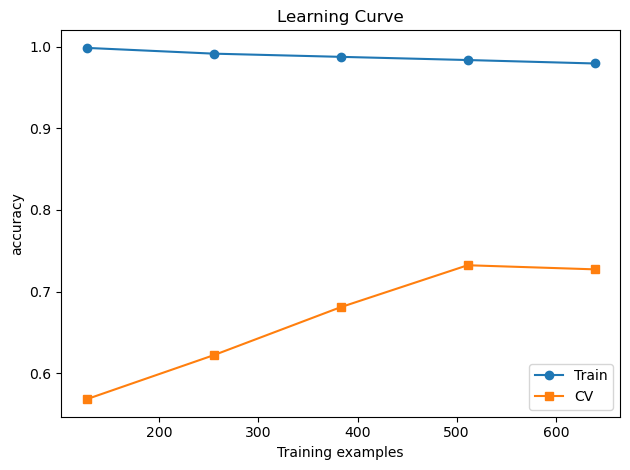

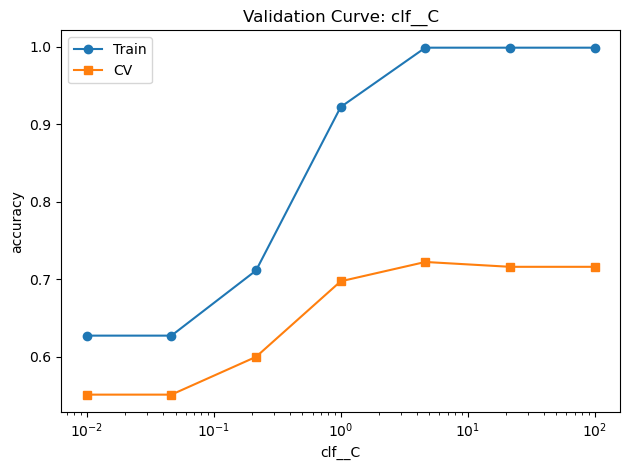

In [8]:
# Pick RBF-SVM if available, else the first best
est = best_estimators.get("RBF-SVM", None) or best_estimators[list(best_estimators.keys())[0]]

plot_learning_curve(est, X_train, y_train, cv=skf, scoring="accuracy")

# Try to draw validation curve over 'clf__C' if it exists
try:
    plot_validation_curve(est, X_train, y_train, cv=skf, param_name="clf__C")
except Exception:
    pass


<Figure size 640x480 with 0 Axes>

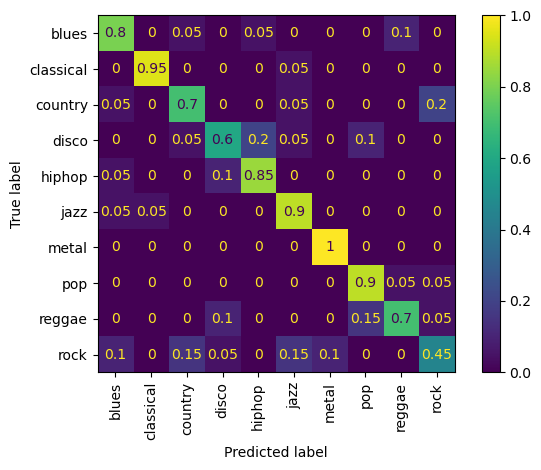

In [9]:
best_name = max(results, key=lambda r: r["test_acc"])["model"]
best = best_estimators[best_name]
y_pred = best.predict(X_test)
labels = sorted(list(np.unique(y_test)))
plot_confusion(y_test, y_pred, labels=labels, normalize="true")


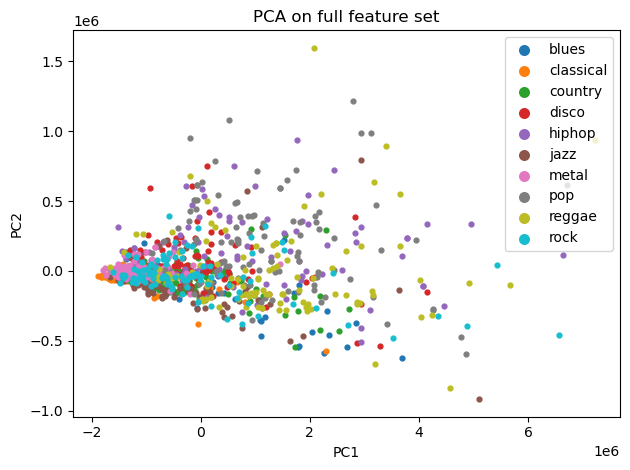

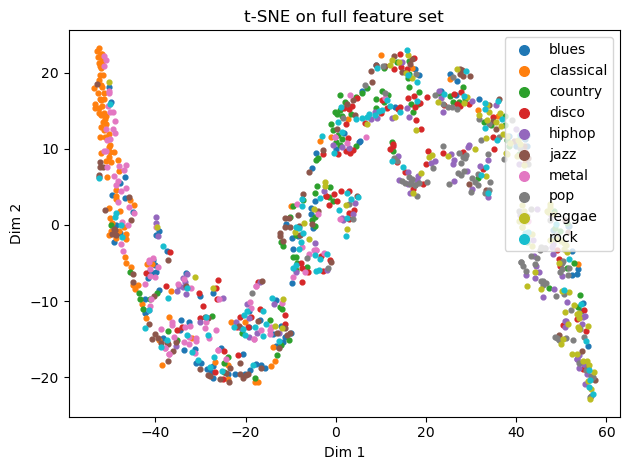

In [10]:
pca_scatter(X, y, title="PCA on full feature set")
tsne_scatter(X, y, title="t-SNE on full feature set", perplexity=30, n_iter=1000)


In [11]:
import joblib
import os
import pandas as pd

# Load features if df is not in memory
if "df" not in globals():
    print("Reloading df from CSV...")
    df = pd.read_csv("../reports/gtzan_features.csv")

# Where to save the trained model
MODEL_DIR = os.path.abspath("../models")
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, "gtzan_best_model.joblib")

# get feature columns
feature_columns = df.drop(columns=["label", "path"]).columns

# Pick the model with best test accuracy
best_name = max(results, key=lambda r: r["test_acc"])["model"]
best_model = best_estimators[best_name]

print("Best model:", best_name)

# Save model + feature order
bundle = {
    "model": best_model,
    "feature_columns": list(feature_columns),
}

joblib.dump(bundle, MODEL_PATH)
print("Saved model bundle to:", MODEL_PATH)


Best model: RandomForest
Saved model bundle to: /Users/hamizs/Documents/genre_classification/models/gtzan_best_model.joblib
